# Import libraries and set configs

In [17]:
import sys

sys.path.append("..")
sys.path.append("../..")

import json
import joblib
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt
import lightgbm as lgb


class CFG:
    # fold - train and validate data on TSS fold scheme
    # inference - train model on all available data and save it
    train_test = "fold"
    n_folds = 5
    min_precision = 0.5
    train_time_years = 4
    test_time_days = 90

# Load the train data

In [18]:
from utils.model_train_utils import load_train_data

train_df, test_date = load_train_data(
    "data/train_df.pkl", "data/profitable_hours.csv", CFG.test_time_days
)

# Train

### Load best parameters from Optuna dataframe

In [19]:
from utils.optimization_utils import load_best_params

params = load_best_params(row_num=2)
params

{'boosting_type': 'dart',
 'class_weight': 'balanced',
 'colsample_bytree': 0.8394998594626718,
 'corr_thresh': 0.9661105675230076,
 'feature_num': 70,
 'high_bound': 0.5274118817870409,
 'is_unbalance': True,
 'learning_rate': 0.1654394619617755,
 'low_bound': 0.0462415423236389,
 'max_bin': 167,
 'max_depth': 4,
 'n_estimators': 2518,
 'num_leaves': 248,
 'reg_alpha': 0.8032956889314465,
 'reg_lambda': 0.0008267673567104,
 'sample_weight': None,
 'subsample': 0.773102643411765}

### Load selected features

In [20]:
from utils.model_train_utils import load_selected_features

fi = pd.read_csv("model/features/feature_importance.csv")
features, feature_dict = load_selected_features(train_df, params, fi)

display(features, len(features))

['funding_rate',
 'weekday',
 'btcdom_high',
 'atr',
 'open',
 'high',
 'btcdom_volume',
 'rsi',
 'low',
 'close',
 'cci',
 'macdhist_prev_4',
 'btcdom_volume_prev_4',
 'low_prev_4',
 'high_prev_12',
 'btcd_volume_prev_24',
 'btcdom_volume_prev_24',
 'btcdom_volume_prev_28',
 'btcdom_volume_prev_32',
 'btcdom_volume_prev_36',
 'stoch_diff_prev_36',
 'btcdom_volume_prev_40',
 'btcdom_volume_prev_44',
 'close_prev_44',
 'stoch_diff_prev_48',
 'cci_prev_56',
 'low_prev_56',
 'high_prev_56',
 'btcdom_volume_prev_68',
 'fng_value_prev_72',
 'btcd_volume_prev_72',
 'btcdom_volume_prev_72',
 'stoch_diff_prev_72',
 'btcdom_volume_prev_80',
 'btcdom_volume_prev_84',
 'cci_prev_84',
 'close_prev_88',
 'btcdom_volume_prev_92',
 'fng_value_prev_96',
 'btcdom_volume_prev_100',
 'fng_value_prev_120',
 'stoch_slowd_prev_128',
 'btcdom_volume_prev_132',
 'btcdom_volume_prev_136',
 'btcdom_volume_prev_148',
 'rsi_prev_148',
 'btcdom_volume_prev_164',
 'fng_value_prev_168',
 'cci_prev_184',
 'btcdom_vol

67

### Prepare model parameters

In [21]:
from utils.model_train_utils import prepare_model_params

params, high_bound, low_bound, sample_weight = prepare_model_params(train_df, params)

### Train process

Training with 67 features
Fold #1
target
1    0.559594
0    0.440406
Name: proportion, dtype: float64
2025-12-12 19:00:00
2026-03-12 18:00:00
[100]	valid_0's binary_logloss: 0.531778	valid_1's binary_logloss: 0.744496
[200]	valid_0's binary_logloss: 0.501813	valid_1's binary_logloss: 0.719306
[300]	valid_0's binary_logloss: 0.47491	valid_1's binary_logloss: 0.723974
[400]	valid_0's binary_logloss: 0.453692	valid_1's binary_logloss: 0.73514
[500]	valid_0's binary_logloss: 0.435316	valid_1's binary_logloss: 0.752523
[600]	valid_0's binary_logloss: 0.42555	valid_1's binary_logloss: 0.748486
[700]	valid_0's binary_logloss: 0.410103	valid_1's binary_logloss: 0.762939
[800]	valid_0's binary_logloss: 0.399176	valid_1's binary_logloss: 0.758492
[900]	valid_0's binary_logloss: 0.385254	valid_1's binary_logloss: 0.772308
[1000]	valid_0's binary_logloss: 0.374333	valid_1's binary_logloss: 0.782607
[1100]	valid_0's binary_logloss: 0.361354	valid_1's binary_logloss: 0.788948
[1200]	valid_0's binary

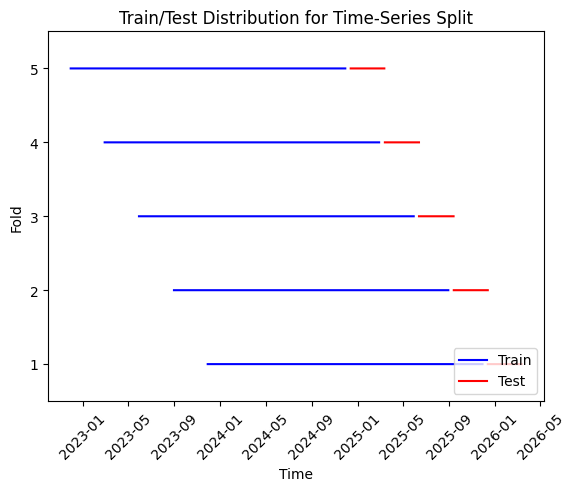

Confident object score: 0.6107755880483153
Total number of confident objects 6292
Total number of profitable objects: 1394
Scores: [11999.999999999995, 27450.0, 2749.999999999998, 12150.000000000005, 15350.000000000004]


In [22]:
import os
from datetime import datetime

from utils.model_train_utils import conf_ppv_npv_acc_score, model_train

with open("model/bybit_tickers.json", "r") as f:
    bybit_tickers = json.load(f)

if CFG.train_test == "fold":
    model, conf_scores, conf_object_nums, oof, val_idxs = model_train(
        train_df[train_df["time"] < test_date], 
        features, 
        params, 
        sample_weight,
        n_folds=CFG.n_folds, 
        low_bound=low_bound,
        high_bound=high_bound, 
        train_test="fold",
        bybit_tickers=bybit_tickers,
        verbose=True,
    )
    y = train_df["target"][val_idxs]
    oof = oof[val_idxs]
    oof_conf_score, oof_conf_obj_num, oof_conf_obj_pct = conf_ppv_npv_acc_score(y, oof, low_bound, high_bound)

    total_profitable = round((2 * oof_conf_score - 1) * oof_conf_obj_num)

    print(80 * "=")
    print(f"Confident object score: {oof_conf_score}\n"
          f"Total number of confident objects {oof_conf_obj_num}\n"
          f"Total number of profitable objects: {total_profitable}")

    scores = [conf_object_num * (conf_score - CFG.min_precision) * 100 for conf_object_num, conf_score in zip(conf_object_nums, conf_scores)]
    print(f"Scores: {scores}")

    # save fold run results
    results_path = "model/train/train_fold_results.csv"
    os.makedirs(os.path.dirname(results_path), exist_ok=True)
    run_row = pd.DataFrame([{
        "run_datetime": datetime.now().isoformat(timespec="minutes"),
        "params": json.dumps(params),
        "high_bound": json.dumps(high_bound),
        "features": json.dumps(features),
        "n_confident_objects": oof_conf_obj_num,
        "n_profitable_objects": total_profitable,
        "scores": json.dumps(scores),
    }])
    run_row.to_csv(results_path, mode="a", header=not os.path.exists(results_path), index=False)
elif CFG.train_test == "inference":
    model, _, _, _, _ = model_train(
        train_df, 
        features, 
        params, 
        sample_weight,
        n_folds=8, 
        low_bound=low_bound,
        high_bound=high_bound, 
        train_test="inference",
        bybit_tickers=bybit_tickers,
        train_time_years=4,
        verbose=False,
    )
    joblib.dump(model, "model/lgbm.pkl")
    # save feature dictionary for further inference
    with open("model/features.json", "w") as f:
        json.dump(feature_dict, f)

### Visualize train results

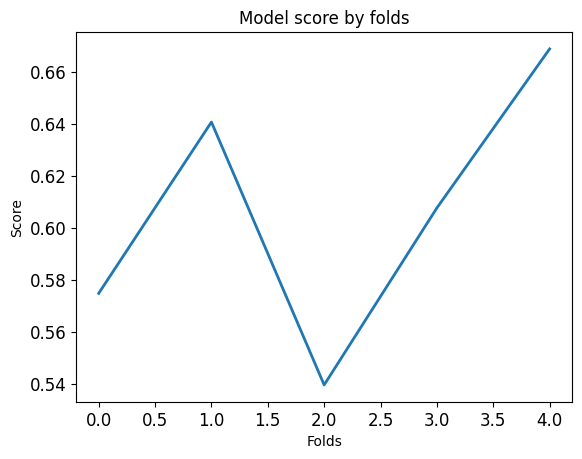

In [23]:
if CFG.train_test == "fold":
    sns.lineplot(x=list(range(len(conf_scores))), y=conf_scores, linewidth=2)

    plt.title("Model score by folds")
    plt.xlabel("Folds")
    plt.xticks(fontsize=12)
    plt.ylabel("Score")
    plt.yticks(fontsize=12)

    plt.show()

### Display PR curve for fold predictions

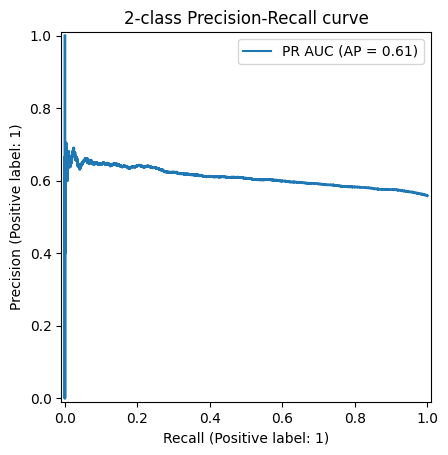

In [24]:
from sklearn.metrics import PrecisionRecallDisplay

if CFG.train_test == "fold":
    disp = PrecisionRecallDisplay.from_predictions(
        y.values, oof, name="PR AUC"
    )
    plt.legend(loc="upper right")
    _ = disp.ax_.set_title("2-class Precision-Recall curve")
    disp.ax_.lines[0].set_linewidth(2)

# vol 1e6 AP=0.61

### Find the best threshold for fold predictions

ic| bound: np.float64(0.41)
    score: 0.59917
    obj_num: 8869
    obj_pct: 0.56
    obj_profit: 1759
ic| bound: np.float64(0.411)
    score: 0.59894
    obj_num: 8844
    obj_pct: 0.56
    obj_profit: 1750
ic| bound: np.float64(0.412)
    score: 0.59939
    obj_num: 8824
    obj_pct: 0.55
    obj_profit: 1754
ic| bound: np.float64(0.413)
    score: 0.59986
    obj_num: 8792
    obj_pct: 0.55
    obj_profit: 1756
ic| bound: np.float64(0.414)
    score: 0.60043
    obj_num: 8767
    obj_pct: 0.55
    obj_profit: 1761
ic| bound: np.float64(0.415)
    score: 0.60023
    obj_num: 8745
    obj_pct: 0.55
    obj_profit: 1753
ic| bound: np.float64(0.416)
    score: 0.60034
    obj_num: 8725
    obj_pct: 0.55
    obj_profit: 1751
ic| bound: np.float64(0.417)
    score: 0.60057
    obj_num: 8700
    obj_pct: 0.55
    obj_profit: 1750
ic| bound: np.float64(0.418)
    score: 0.6009
    obj_num: 8682
    obj_pct: 0.55
    obj_profit: 1752
ic| bound: np.float64(0.419)
    score: 0.60111
    obj_n

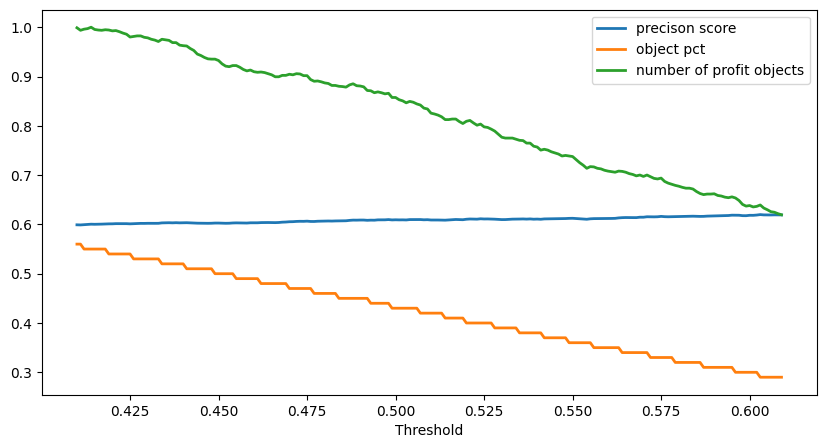

In [25]:
from icecream import ic

if CFG.train_test == "fold":
    figsize = (10, 5)
    plt.figure(figsize=figsize)
    
    score_list = list()
    obj_num_list = list()
    obj_pct_list = list()
    obj_profit_list = list()
    max_obj_profit = 0
    for hb in np.arange(0.41, 0.61, 0.001):
        score, obj_num, obj_pct = conf_ppv_npv_acc_score(y.reset_index(drop=True), oof, 0, hb)
        if score == 0:
            obj_num = 0
            obj_pct = 0
        bound, score, obj_num, obj_pct = round(hb, 4), round(score, 5), round(obj_num, 2), round(obj_pct, 2)
        obj_profit = round((2 * score - 1) * obj_num)
        score_list.append(score)
        obj_num_list.append(obj_num)
        obj_pct_list.append(obj_pct)
        obj_profit_list.append(obj_profit)
        max_obj_profit = max(max_obj_profit, obj_profit)
        ic(bound, score, obj_num, obj_pct, obj_profit)

    obj_profit_list = [o / max_obj_profit for o in obj_profit_list]
    line1 = plt.plot(np.arange(0.41, 0.61, 0.001), score_list, label="precison score", linewidth=2)
    line2 = plt.plot(np.arange(0.41, 0.61, 0.001), obj_pct_list, label="object pct", linewidth=2)
    line3 = plt.plot(np.arange(0.41, 0.61, 0.001), obj_profit_list, label="number of profit objects", linewidth=2)
    
    plt.legend()
    plt.xlabel("Threshold")
    plt.show()

### Model feature importance

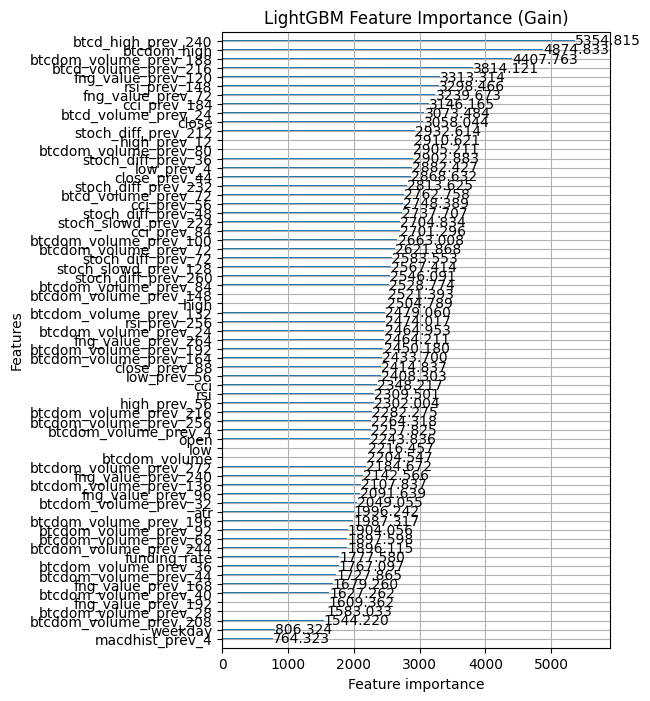

In [26]:
if CFG.train_test == "fold":
    lgb.plot_importance(model, importance_type="gain", figsize=(5, 8), title="LightGBM Feature Importance (Gain)")
    plt.show()

# Error analysis

### Distribution of model pseudo-residuals

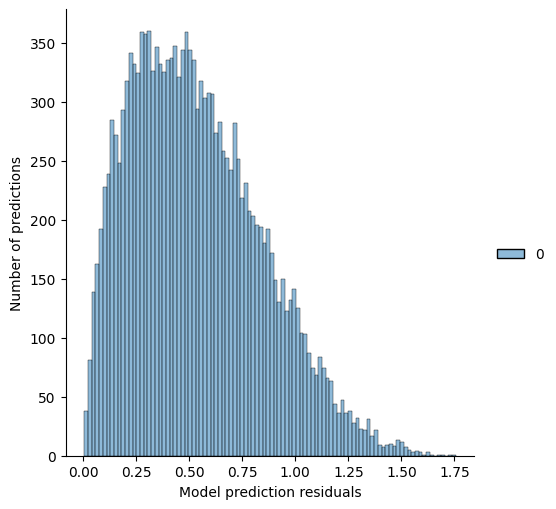

In [27]:
from utils.model_test_utils import logloss

if CFG.train_test == "fold":
    y_true = y.values.reshape(-1, 1)
    residuals = -logloss(y_true, oof)

    sns.displot(np.log1p(residuals), bins=100)

    plt.xlabel("Model prediction residuals")
    plt.xticks(fontsize=10)
    plt.ylabel("Number of predictions")
    plt.yticks(fontsize=10)

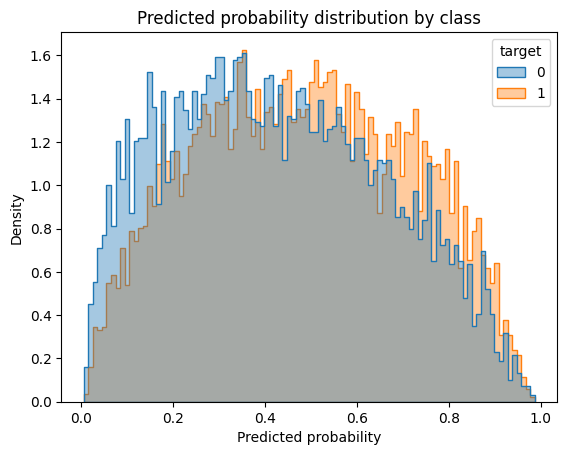

In [28]:
if CFG.train_test == "fold":
    prob_df = pd.DataFrame({"pred": oof.squeeze(), "target": y})

    # common_norm=False normalizes each class separately so the imbalanced
    # classes are comparable and their separation is visible
    sns.histplot(
        data=prob_df, x="pred", hue="target",
        bins=100, stat="density", common_norm=False,
        element="step", alpha=0.4,
    )

    plt.title("Predicted probability distribution by class")
    plt.xlabel("Predicted probability")
    plt.xticks(fontsize=10)
    plt.ylabel("Density")
    plt.yticks(fontsize=10)
    plt.show()

### Calibration curve

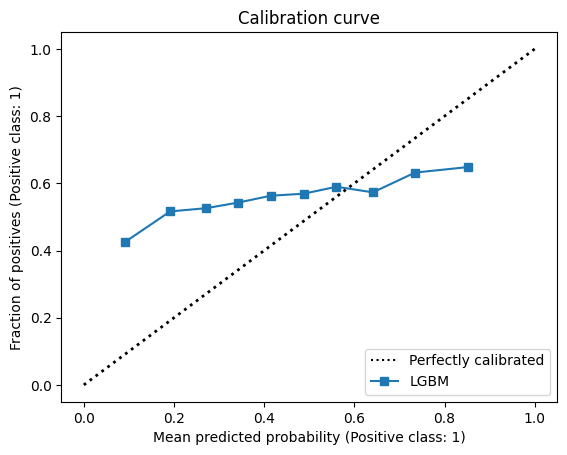

In [29]:
from sklearn.calibration import CalibrationDisplay

if CFG.train_test == "fold":
    # strategy="quantile" -> equal-count bins, since the probabilities
    # are concentrated in the mid-range rather than spread evenly
    disp = CalibrationDisplay.from_predictions(
        y, oof.squeeze(), n_bins=10, strategy="quantile", name="LGBM",
    )
    disp.ax_.set_title("Calibration curve")
    disp.ax_.lines[0].set_linewidth(2)
    plt.show()

### Show worst predictions

In [30]:
if CFG.train_test == "fold":
    prob_df["residuals"] = np.abs(prob_df["target"] - prob_df["pred"])
    worst_idxs = prob_df.query("pred >= @high_bound").sort_values("residuals", ascending=False).head(20).index
    worst_idxs_df = train_df.loc[worst_idxs, ["time", "ticker", "target", "ttype"]]
    worst_idxs_df["pred"] = prob_df.query("pred >= @high_bound").sort_values("residuals", ascending=False).head(20)["pred"]
    display(worst_idxs_df)

,time,ticker,target,ttype,pred
17284,2024-12-28 15:00:00,SAFEUSDT,0,buy,0.987228
40908,2026-02-28 08:00:00,IOTXUSDT,0,sell,0.980603
17286,2024-12-28 16:00:00,ZECUSDT,0,buy,0.974246
22280,2025-03-29 17:00:00,KAVAUSDT,0,buy,0.972650
33900,2025-11-26 19:00:00,ACEUSDT,0,buy,0.972575
23061,2025-04-14 07:00:00,ARKUSDT,0,buy,0.970726
39702,2026-02-11 16:00:00,1000BONKUSDT,0,buy,0.969353
39747,2026-02-11 16:00:00,SNXUSDT,0,buy,0.966977
40660,2026-02-24 15:00:00,AGIUSDT,0,buy,0.966627
30818,2025-10-11 02:00:00,SPKUSDT,0,buy,0.963381


### Show best predictions

In [31]:
if CFG.train_test == "fold":
    best_idxs = prob_df.query("pred >= @high_bound").sort_values("residuals").head(20).index
    best_idxs_df = train_df.loc[best_idxs, ["time", "ticker", "target", "ttype"]]
    best_idxs_df["pred"] = prob_df.query("pred >= @high_bound").sort_values("residuals").head(20)["pred"]
    display(best_idxs_df)

,time,ticker,target,ttype,pred
19059,2025-01-28 18:00:00,1000000MOGUSDT,1,buy,0.983003
39882,2026-02-14 08:00:00,RAYDIUMUSDT,1,sell,0.981310
27182,2025-07-30 00:00:00,SAFEUSDT,1,buy,0.976849
23521,2025-05-04 14:00:00,TUSDT,1,buy,0.976002
26826,2025-07-24 03:00:00,USTCUSDT,1,buy,0.969695
19909,2025-02-11 19:00:00,XCNUSDT,1,buy,0.969126
39880,2026-02-14 08:00:00,MUBARAKUSDT,1,sell,0.968014
27176,2025-07-29 23:00:00,RENDERUSDT,1,buy,0.967349
39878,2026-02-14 08:00:00,GALAUSDT,1,sell,0.965105
33823,2025-11-22 14:00:00,1000RATSUSDT,1,buy,0.964524


# Compare indicator / signal values for bot and optimizer

In [32]:
# import fireducks.pandas as pd
# from signals.find_signal import SignalFactory

# ttype = "sell"
# ticker = "BADGERUSDT"
# month = 7
# day = 15
# hour = 23
# configs = ConfigFactory.factory(environ).configs

# x = pd.read_csv(f"../bot/ticker_dataframes/{ticker}_1h_{ttype}_{month}_{day}_{hour}.csv").drop(columns=["Unnamed: 0"]).reset_index(drop=True)
# y = pd.read_csv(f"../bot/ticker_dataframes/{ticker}_4h_{ttype}_{month}_{day}_{hour}.csv").drop(columns=["Unnamed: 0"]).reset_index(drop=True)

# # add Volume24
# vol24 = indicators.Volume24(ttype, configs)
# x = vol24.get_indicator(x, "", "1h", 0)
# # add Pattern
# pattern = indicators.Pattern(ttype, configs)
# x = pattern.get_indicator(x, "", "", 0)
# # add trend
# trend = indicators.Trend(ttype, configs)
# y = trend.get_indicator(y, "", "", 0)

# # cols = ["time", "open", "high", "low", "close", "volume", "rsi", "stoch_slowk", "stoch_slowd", "linear_reg", "linear_reg_angle", "macd", "macdsignal", "macdhist"]
# cols = ["time", "open", "high", "low", "close", "volume", "linear_reg", "linear_reg_angle", "high_max", "low_min", "volume_24"]

# higher_features = ["time_4h", "linear_reg", "linear_reg_angle", "macd", "macdhist",  "macd_dir", 
#                    "macdsignal", "macdsignal_dir"]
# x["time"] = pd.to_datetime(x["time"])
# y["time"] = pd.to_datetime(y["time"])
# y["time_4h"] = y["time"] + pd.to_timedelta(3, unit="h")
# x[["time"] + higher_features] = pd.merge(x[["time"]], y[higher_features], how="left", left_on="time", right_on="time_4h")

# # x = x.drop(columns=["time_4h"])
# # y = y.drop(columns=["time_4h"])
# x = x.ffill()
# x = x.reset_index(drop=True)

# # get Swing pattern
# pattern = SignalFactory().factory("Pattern", ttype, configs)
# pattern_points = pattern.find_signal(x)
# trend = SignalFactory().factory("Trend", ttype, configs)
# trend_points = trend.find_signal(x)
# idxs = np.where((pattern_points > 0) & (trend_points > 0))
# display(x.loc[idxs[0], cols])

# z = pd.read_pickle(f"data/tickers/{ticker}_1h.pkl")
# v = pd.read_pickle(f"data/tickers/{ticker}_4h.pkl")

# # add Volume24
# vol24 = indicators.Volume24(ttype, configs)
# z = vol24.get_indicator(z, "", "1h", 0)
# # add Pattern
# pattern = indicators.Pattern(ttype, configs)
# z = pattern.get_indicator(z, "", "", 0)
# # add Trend
# trend = indicators.Trend(ttype, configs)
# v = trend.get_indicator(v, "", "", 0)
# z.tail(48)

# v["time_4h"] = v["time"] + pd.to_timedelta(3, unit="h")
# z[["time"] + higher_features] = pd.merge(z[["time"]], y[higher_features], how="left", left_on="time", right_on="time_4h")

# z = z.drop(columns=["time_4h"])
# v = v.drop(columns=["time_4h"])
# z = z.ffill()
# z = z.reset_index(drop=True)

# # get Swing pattern
# pattern = SignalFactory().factory("Pattern", ttype, configs)
# pattern_points = pattern.find_signal(z)
# trend = SignalFactory().factory("Trend", ttype, configs)
# trend_points = trend.find_signal(z)
# idxs = np.where((pattern_points > 0) & (trend_points > 0))
# display(z.loc[idxs[0], cols])